<a href="https://colab.research.google.com/github/AashiGarg-tech/Plant-disease-classification-model/blob/main/Untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Step 1: Install Libraries and Download Data

!pip install kaggle

print("Please upload your 'kaggle.json' file")
from google.colab import files
files.upload() # This will prompt you to upload your kaggle.json

# Move the API key to the correct folder
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Downloading dataset...")
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset

print("Unzipping dataset... (This is the slow part)")
# Unzip the file (q = quiet mode)
!unzip -q new-plant-diseases-dataset.zip

print("Data is ready.")

Please upload your 'kaggle.json' file


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
 99% 2.68G/2.70G [00:36<00:00, 288MB/s]
100% 2.70G/2.70G [00:37<00:00, 78.2MB/s]
Unzipping dataset... (This is the slow part)
Data is ready.


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
import matplotlib.pyplot as plt
import os


# -----------------------------
# STEP 4: SET CORRECT DIRECTORY
# -----------------------------
# This dataset has nested folders, so we use the correct path.
base_dir = "new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)"

train_dir = os.path.join(base_dir, "train")
valid_dir = os.path.join(base_dir, "valid")


# -----------------------------
# STEP 5: DATA PREPROCESSING
# -----------------------------
# We reduce image size & batch size to avoid RAM issues.
IMG_SIZE = (128, 128)
BATCH_SIZE = 16


In [ ]:
print("Loading training dataset...")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)

print("Loading validation dataset...")
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    valid_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)
# Extract class names
class_names = train_dataset.class_names
print("Classes found:", len(class_names))
print(class_names[:10])

Loading training dataset...
Found 70295 files belonging to 38 classes.
Loading validation dataset...
Found 17572 files belonging to 38 classes.
Classes found: 38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight']


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.shuffle(1000).prefetch(AUTOTUNE)
validation_dataset = validation_dataset.prefetch(AUTOTUNE)


In [ ]:
num_classes = len(class_names)

model = Sequential([
    layers.Rescaling(1./255, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()



/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │        19,494 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,958,310 (49.43 MB)

 Trainable params: 12,958,310 (49.43 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

epochs = 10

# Save the BEST model automatically
checkpoint_folder = "/content/drive/MyDrive/best_plant_disease_model_weights"
os.makedirs(checkpoint_folder, exist_ok=True)

checkpoint_path = os.path.join(
    checkpoint_folder,
    "best_model_epoch_{epoch:02d}_val_acc_{val_accuracy:.4f}.keras"
)

checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=False,
    mode='max',
    verbose=1
)

print("Training the model...")
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=epochs,
    callbacks=[checkpoint_callback]
)


Training the model...
Epoch 1/10
4392/4394 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5970 - loss: 1.4024
Epoch 1: val_accuracy improved from -inf to 0.87884, saving model to /content/drive/MyDrive/best_plant_disease_model_weights/best_model_epoch_01_val_acc_0.8788.keras
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 90s 17ms/step - accuracy: 0.5971 - loss: 1.4020 - val_accuracy: 0.8788 - val_loss: 0.3750
Epoch 2/10
4393/4394 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9152 - loss: 0.2645
Epoch 2: val_accuracy improved from 0.87884 to 0.91987, saving model to /content/drive/MyDrive/best_plant_disease_model_weights/best_model_epoch_02_val_acc_0.9199.keras
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 83s 16ms/step - accuracy: 0.9152 - loss: 0.2645 - val_accuracy: 0.9199 - val_loss: 0.2652
Epoch 3/10
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9494 - loss: 0.1541
Epoch 3: val_accuracy improved from 0.91987 to 0.92283, saving model to /content/drive/MyDrive/best_plant_disease_model_weights/best_m

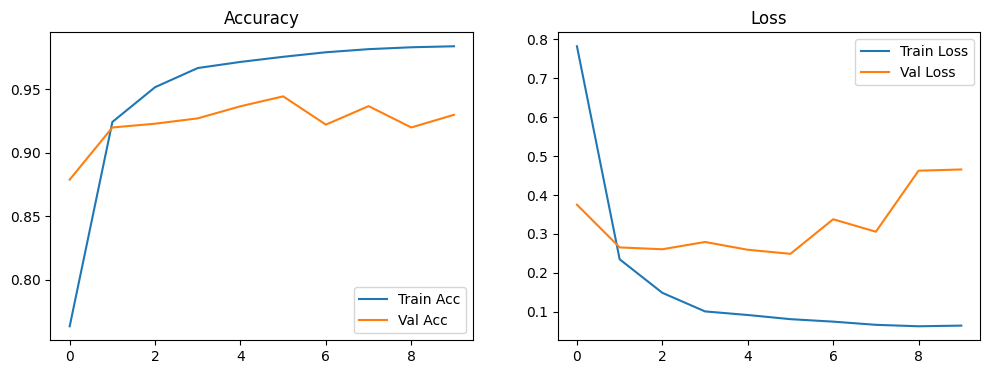

Best Validation Accuracy: 94.43432688713074 %


In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train Acc')
plt.plot(epochs_range, val_acc, label='Val Acc')
plt.legend()
plt.title("Accuracy")

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Val Loss')
plt.legend()
plt.title("Loss")

plt.show()

best_val_accuracy = max(val_acc)
print("Best Validation Accuracy:", best_val_accuracy * 100, "%")


In [ ]:
# Step 8 (New): Load Your BEST Model

import os
from tensorflow.keras.models import load_model
from google.colab import drive

# 1. Mount Drive
# drive.mount('/content/drive', force_remount=True)

# 2. Define the path where the BEST model was saved
checkpoint_folder = "/content/drive/MyDrive/best_plant_disease_model_weights"

# --- !!! THIS IS YOUR CORRECT FILENAME (from the !ls command) !!! ---
best_model_filename = 'best_model_epoch_06_val_acc_0.9443.keras'
# ---

best_model_path = os.path.join(checkpoint_folder, best_model_filename)

# 3. Load the model with the best performance
try:
    best_model = load_model(best_model_path)
    print(f"Successfully loaded model with best validation accuracy: {best_model_filename}")
except Exception as e:
    print(f"Error loading model: {e}")

Error loading model: File not found: filepath=/content/drive/MyDrive/best_plant_disease_model_weights/best_model_epoch_06_val_acc_0.9443.keras. Please ensure the file is an accessible `.keras` zip file.


In [ ]:
# Step 9: Load the Best Accuracy Model for Predictions

import os
from tensorflow.keras.models import load_model

# 1. Define the path where the BEST model was saved
checkpoint_folder = "/content/drive/MyDrive/best_plant_disease_model_weights"

# --- !!! THIS IS THE FIX !!! ---
# Find the exact filename in your Google Drive and paste it here
best_model_filename = 'best_model_epoch_06_val_acc_0.9443.keras'
# For example: 'best_model_epoch_05_val_acc_0.9370.keras'
# --- END OF FIX ---

best_model_path = os.path.join(checkpoint_folder, best_model_filename)

# 2. Load the model with the best performance
try:
    best_model = load_model(best_model_path)
    print(f"Successfully loaded model with best validation accuracy: {best_model_filename}")
except Exception as e:
    print(f"Error loading model: {e}")
    print("---")
    print("Is this your filename? ->", best_model_filename)
    print("If not, please copy/paste the exact filename from Google Drive and re-run this cell.")

# Now you can use 'best_model.predict()' for all future high-accuracy predictions.

Error loading model: File not found: filepath=/content/drive/MyDrive/best_plant_disease_model_weights/best_model_epoch_06_val_acc_0.9443.keras. Please ensure the file is an accessible `.keras` zip file.
---
Is this your filename? -> best_model_epoch_06_val_acc_0.9443.keras
If not, please copy/paste the exact filename from Google Drive and re-run this cell.


In [ ]:
print("Train Accuracy:", history.history['accuracy'][-1])
print("Val Accuracy:", history.history['val_accuracy'][-1])


Train Accuracy: 0.9837257266044617
Val Accuracy: 0.9298315644264221


1019371/1019371 ━━━━━━━━━━━━━━━━━━━━ 2s 2us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step

--- Prediction from your BEST (94.4%) Model ---

This leaf is most likely: Corn_(maize)___Common_rust_
Confidence: 99.57%


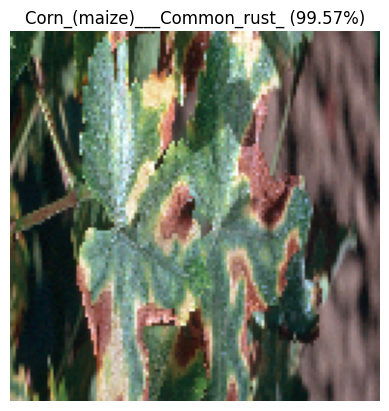

In [ ]:
# Step 10 (Corrected): Test on a Single Image (using the 93.7% BEST Model)

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# --- 1. Paste the URL of your test image here ---
image_url = "https://ipm.ucanr.edu/PMG/IMAGES/U/D-GR-UNKN-FO.003banner.png"

# --- 2. Download and Preprocess the Image ---
try:
    image_path = tf.keras.utils.get_file(
        'test_image_6',
        origin=image_url
    )

    # Load and resize the image to 128x128
    img = tf.keras.utils.load_img(
        image_path,
        target_size=IMG_SIZE # (128, 128)
    )

    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0) # Create a batch

    # --- 3. Get the Model's Prediction ---
    # We are using 'best_model.predict()'
    predictions = best_model.predict(img_array)

    # --- !!! CRITICAL FIX !!! ---
    # Do NOT use tf.nn.softmax again.
    # Just take the predictions directly.
    score = predictions[0]
    # --- END OF FIX ---

    # --- 4. Show the Results ---
    top_class = class_names[np.argmax(score)]
    top_confidence = 100 * np.max(score)

    print("\n--- Prediction from your BEST (94.4%) Model ---")
    print(f"\nThis leaf is most likely: {top_class}")
    print(f"Confidence: {top_confidence:.2f}%")

    plt.imshow(img)
    plt.title(f"{top_class} ({top_confidence:.2f}%)")
    plt.axis("off")
    plt.show()

except Exception as e:
    print(f"Error: Could not load image from URL. Details: {e}")

In [ ]:
!ls /content/drive/MyDrive/best_plant_disease_model_weights


ls: cannot access '/content/drive/MyDrive/best_plant_disease_model_weights': No such file or directory


In [ ]:
print(class_names)


['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Sp

In [ ]:
pred = best_model.predict(img_array)[0]
print(np.argmax(pred))
print(np.max(pred))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
16
0.67622155


In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import confusion_matrix

y_true = []
y_pred = []

# Go through the validation dataset batch by batch
for images, labels in validation_dataset:
    preds = best_model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

# Make confusion matrix
cm = confusion_matrix(y_true, y_pred)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 959ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━

In [ ]:
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)
for class_name, acc in zip(class_names, per_class_accuracy):
    print(f"{class_name}: {acc*100:.2f}%")


Apple___Apple_scab: 93.06%
Apple___Black_rot: 97.38%
Apple___Cedar_apple_rust: 95.45%
Apple___healthy: 91.04%
Blueberry___healthy: 98.46%
Cherry_(including_sour)___Powdery_mildew: 98.57%
Cherry_(including_sour)___healthy: 96.27%
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 93.41%
Corn_(maize)___Common_rust_: 98.95%
Corn_(maize)___Northern_Leaf_Blight: 85.32%
Corn_(maize)___healthy: 99.78%
Grape___Black_rot: 98.73%
Grape___Esca_(Black_Measles): 94.17%
Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 99.77%
Grape___healthy: 99.53%
Orange___Haunglongbing_(Citrus_greening): 98.01%
Peach___Bacterial_spot: 94.12%
Peach___healthy: 98.61%
Pepper,_bell___Bacterial_spot: 91.63%
Pepper,_bell___healthy: 94.37%
Potato___Early_blight: 96.91%
Potato___Late_blight: 91.96%
Potato___healthy: 94.96%
Raspberry___healthy: 97.53%
Soybean___healthy: 98.22%
Squash___Powdery_mildew: 97.70%
Strawberry___Leaf_scorch: 94.82%
Strawberry___healthy: 98.46%
Tomato___Bacterial_spot: 91.76%
Tomato___Early_blight: 85.

In [ ]:
!ls -lh /content/drive/MyDrive/best_plant_disease_model_weights


total 891M
-rw-r--r-- 1 root root 149M Nov 23 10:37 best_model_epoch_01_val_acc_0.8788.keras
-rw-r--r-- 1 root root 149M Nov 23 10:39 best_model_epoch_02_val_acc_0.9199.keras
-rw-r--r-- 1 root root 149M Nov 23 10:40 best_model_epoch_03_val_acc_0.9228.keras
-rw-r--r-- 1 root root 149M Nov 23 10:41 best_model_epoch_04_val_acc_0.9270.keras
-rw-r--r-- 1 root root 149M Nov 23 10:43 best_model_epoch_05_val_acc_0.9365.keras
-rw-r--r-- 1 root root 149M Nov 23 10:45 best_model_epoch_06_val_acc_0.9443.keras
